In [1]:
import import_ipynb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
from datetime import datetime
from collections import defaultdict
from scipy.optimize import curve_fit
from functools import reduce

from functions import *

In [2]:
Nqbits = 6
Ntsteps = 3
mid = Nqbits - 2

In [3]:
ferm_num_m1125_e005 = np.load('data/ferm_num_exact_no_noise_no_knit.npy')
bs_error_m1125_e005=np.load('data/bs_error_exact_no_noise_no_knit.npy')
# ferm_num_exact_no_noise_no_knit = ferm_num_exact_no_noise_no_knit[:9]
# bs_error_exact_no_noise_no_knit = bs_error_exact_no_noise_no_knit[:9]

In [66]:
hank_blue = (0, 114/256, 178/256)
hank_orange = (213/256, 94/256, 0)
hank_green = (0, 178/256, 114/256)

# mass extraction (exact) at $m=1$ and $m=1.125$

## get data

In [5]:
def time_evol_e0p005(mass):
    epsilon = 0.05
    ferm_num = np.zeros(0)
    bs_error = np.zeros(0)
    for i in range(33):
        #print(i)
        step = int(4*i)
        num_shots = 1024**2 # CHANGE THIS BACK!!!
        circuit = trotter_stepper(step, Nqbits, epsilon, mass, mid).decompose().decompose()
        circuit.measure_all()
        res = do_run(circuit, num_shots)
        ferm_num=np.append(ferm_num, fermion_number(res, mid))
        bs_error=np.append(bs_error,bootstrap_error(res, mid, num_shots))
    return ferm_num, bs_error

In [6]:
""" load (or produce) data for m=1 """

try: 
    ferm_num_m1p0_e0p005, bs_error_m1p0_e0p005 = np.load('mass_scan_plot_data/ferm_num_m1p0_e0p005.npy'), np.load('mass_scan_plot_data/bs_error_m1p0_e0p005.npy')
except FileNotFoundError:
    ferm_num_m1p0_e0p005, bs_error_m1p0_e0p005 = time_evol_e0p005(1)
    np.save('mass_scan_plot_data/ferm_num_m1p0_e0p005.npy', ferm_num_m1p0_e0p005)
    np.save('mass_scan_plot_data/bs_error_m1p0_e0p005.npy', bs_error_m1p0_e0p005)

In [7]:
""" load (or produce) data for m=1.125 """

try: 
    ferm_num_m1p125_e0p005, bs_error_m1p125_e0p005 = np.load('mass_scan_plot_data/ferm_num_m1p125_e0p005.npy'), np.load('mass_scan_plot_data/bs_error_m1p125_e0p005.npy')
except FileNotFoundError:
    ferm_num_m1p125_e0p005, bs_error_m1p125_e0p005 = time_evol_e0p005(1.125)
    np.save('mass_scan_plot_data/ferm_num_m1p125_e0p005.npy', ferm_num_m1p125_e0p005)
    np.save('mass_scan_plot_data/bs_error_m1p125_e0p005.npy', bs_error_m1p125_e0p005)

In [8]:
""" load (or produce) data for m=1.25 """

try: 
    ferm_num_m1p25_e0p005, bs_error_m1p25_e0p005 = np.load('mass_scan_plot_data/ferm_num_m1p25_e0p005.npy'), np.load('mass_scan_plot_data/bs_error_m1p25_e0p005.npy')
except FileNotFoundError:
    ferm_num_m1p25_e0p005, bs_error_m1p25_e0p005 = time_evol_e0p005(1.25)
    np.save('mass_scan_plot_data/ferm_num_m1p25_e0p005.npy', ferm_num_m1p25_e0p005)
    np.save('mass_scan_plot_data/bs_error_m1p25_e0p005.npy', bs_error_m1p25_e0p005)

## fit to get mass-like parameter

In [9]:
# # fit Ansatz
# def fit_func(x, A, B, C, D, E):
#     return A*np.exp(-B*x) * np.cos(C*x) + D + E*x

# fit Ansatz
def fit_func_full(x, A, B, C, D, E):
    return A*np.exp(-B*x) * np.cos(C*x) + D + E*x

# fit Ansatz
def fit_func_trunc(x, A, C, D):
    return A * np.cos(C*x) + D

### $m=1$

In [10]:
# exact parameters from all 33 data points
params_m1p0_e0p005_full, _ = curve_fit(fit_func_full,\
                                       [item*0.2 for item in range(len(ferm_num_m1p0_e0p005))],\
                                       ferm_num_m1p0_e0p005,\
                                       sigma=bs_error_m1p0_e0p005)

In [11]:
params_m1p0_e0p005_full

array([-0.0224192 ,  0.00802858,  1.77045717,  0.5230205 , -0.00516535])

In [12]:
# parameters extracted from truncated data of only first 9 points; uses full answer as starting guess
params_m1p0_e0p005_trunc, _ = curve_fit(fit_func_trunc,\
                                        [item*0.2 for item in range(9)],\
                                        ferm_num_m1p0_e0p005[:9],\
                                        sigma=bs_error_m1p0_e0p005[:9])

In [13]:
params_m1p0_e0p005_trunc

array([-0.01802507, -1.8936274 ,  0.51763593])

In [14]:
np.abs(1.77045717-1.8936274)/1.77045717

np.float64(0.06956973152872144)

In [15]:
# exact parameters from all 33 data points
params_m1p0_e0p005_alt, cov_m1p0_e0p005_full = curve_fit(fit_func_trunc,\
                                                          [item*0.2 for item in range(len(ferm_num_m1p0_e0p005))],\
                                                          ferm_num_m1p0_e0p005,\
                                                          p0=params_m1p0_e0p005_trunc)

In [16]:
params_m1p0_e0p005_alt

array([-0.0188639 , -1.82365139,  0.50701254])

### $m=1.125$

In [17]:
# exact parameters from all 33 data points
params_m1p125_e0p005_full, _ = curve_fit(fit_func_full,\
                                         [item*0.2 for item in range(len(ferm_num_m1p125_e0p005))],\
                                         ferm_num_m1p125_e0p005,\
                                         sigma=bs_error_m1p125_e0p005)

In [18]:
params_m1p125_e0p005_full

array([-0.01958994, -0.00256387,  1.87138898,  0.51953809, -0.00403299])

In [19]:
# parameters extracted from truncated data of only first 9 points; uses full answer as starting guess
params_m1p125_e0p005_trunc, _ = curve_fit(fit_func_trunc,\
                                          [item*0.2 for item in range(9)],\
                                          ferm_num_m1p125_e0p005[:9],\
                                          sigma=bs_error_m1p125_e0p005[:9])

In [20]:
params_m1p125_e0p005_trunc

array([-0.01649466, -1.95503796,  0.51620237])

In [21]:
np.abs(1.87138898-1.95503796)/1.87138898

np.float64(0.04469887388136697)

In [22]:
# exact parameters from all 33 data points
params_m1p125_e0p005_alt, _ = curve_fit(fit_func_trunc,\
                                        [item*0.2 for item in range(len(ferm_num_m1p125_e0p005))],\
                                        ferm_num_m1p125_e0p005,\
                                        p0=params_m1p125_e0p005_trunc,)

In [23]:
params_m1p125_e0p005_alt

array([-0.01859054, -1.92500998,  0.50717501])

### $m=1.25$

In [50]:
# exact parameters from all 33 data points
params_m1p25_e0p005_full, _ = curve_fit(fit_func_full,\
                                         [item*0.2 for item in range(len(ferm_num_m1p25_e0p005))],\
                                         ferm_num_m1p25_e0p005,\
                                         sigma=bs_error_m1p25_e0p005)

In [52]:
params_m1p25_e0p005_full

array([-0.01716946, -0.00936393,  1.97680035,  0.51678306, -0.00319563])

In [62]:
# parameters extracted from truncated data of only first 9 points; uses full answer as starting guess
params_m1p25_e0p005_trunc, _ = curve_fit(fit_func_trunc,\
                                          [item*0.2 for item in range(9)],\
                                          ferm_num_m1p25_e0p005[:9],\
                                          sigma=bs_error_m1p25_e0p005[:9],\
                                          p0=[params_m1p25_e0p005_full[0], params_m1p25_e0p005_full[2], params_m1p25_e0p005_full[3]])

In [63]:
params_m1p25_e0p005_trunc

array([-0.01470736,  2.09635729,  0.51432608])

In [83]:
np.abs(1.97680035-2.09635729)/1.97680035

np.float64(0.060480027737752996)

In [58]:
# exact parameters from all 33 data points
params_m1p25_e0p005_alt, _ = curve_fit(fit_func_trunc,\
                                        [item*0.2 for item in range(len(ferm_num_m1p25_e0p005))],\
                                        ferm_num_m1p25_e0p005,\
                                        p0=params_m1p25_e0p005_trunc,)

In [59]:
params_m1p125_e0p005_alt

array([-0.01859054, -1.92500998,  0.50717501])

## plots

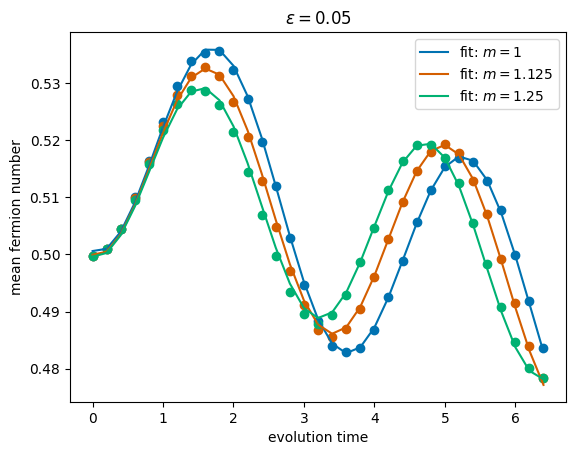

In [89]:
full_steps = [0.2*i for i in range(33)] 

plt.scatter(full_steps, ferm_num_m1p0_e0p005, color=hank_blue)
plt.errorbar(full_steps, ferm_num_m1p0_e0p005, bs_error_m1p0_e0p005, alpha=0.2, ls='none', color=hank_blue)
plt.plot(full_steps, [fit_func_full(item, *params_m1p0_e0p005_full) for item in full_steps], color=hank_blue, label = 'fit: $m=1$')

plt.scatter(full_steps, ferm_num_m1p125_e0p005, color=hank_orange)
plt.errorbar(full_steps, ferm_num_m1p125_e0p005, bs_error_m1p125_e0p005, alpha=0.2, ls='none', color=hank_orange)
plt.plot(full_steps, [fit_func_full(item, *params_m1p125_e0p005_full) for item in full_steps], color=hank_orange, label = 'fit: $m=1.125$')

plt.scatter(full_steps, ferm_num_m1p25_e0p005, color=hank_green)
plt.errorbar(full_steps, ferm_num_m1p25_e0p005, bs_error_m1p25_e0p005, alpha=0.2, ls='none', color=hank_green)
plt.plot(full_steps, [fit_func_full(item, *params_m1p25_e0p005_full) for item in full_steps], color=hank_green, label = 'fit: $m=1.25$')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$\\epsilon=0.05$')

plt.legend()
plt.savefig('figures/mass_scan.pdf')
plt.show()

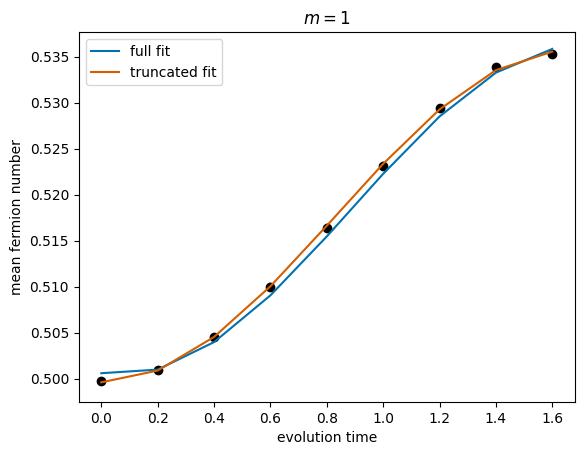

In [68]:
short_steps = np.linspace(0, 1.6, 9)

plt.scatter(short_steps, ferm_num_m1p0_e0p005[:9], color='black')
plt.errorbar(short_steps, ferm_num_m1p0_e0p005[:9], bs_error_m1p0_e0p005[:9], alpha=0.2, ls='none', color='black')
plt.plot(short_steps, [fit_func_full(0.2*i, *params_m1p0_e0p005_full) for i in range(9)], color=hank_blue, label = 'full fit')
plt.plot(short_steps, [fit_func_trunc(0.2*i, *params_m1p0_e0p005_trunc) for i in range(9)], color=hank_orange, label = 'truncated fit')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m=1$')

plt.legend()
plt.show()

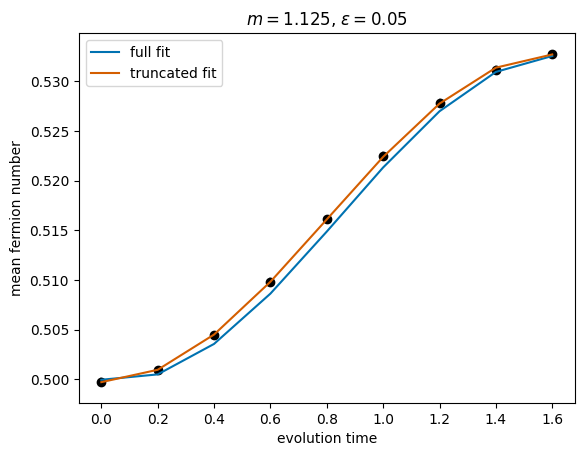

In [92]:
short_steps = np.linspace(0, 1.6, 9)

plt.scatter(short_steps, ferm_num_m1p125_e0p005[:9], color='black')
plt.errorbar(short_steps, ferm_num_m1p125_e0p005[:9], bs_error_m1p125_e0p005[:9], alpha=0.2, ls='none', color='black')
plt.plot(short_steps, [fit_func_full(0.2*i, *params_m1p125_e0p005_full) for i in range(9)], color=hank_blue, label = 'full fit')
plt.plot(short_steps, [fit_func_trunc(0.2*i, *params_m1p125_e0p005_trunc) for i in range(9)], color=hank_orange, label = 'truncated fit')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m=1.125$, $\\epsilon=0.05$')

plt.legend()
plt.show()

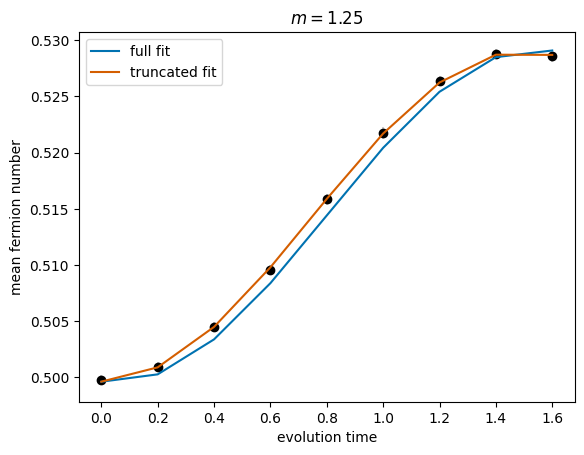

In [90]:
short_steps = np.linspace(0, 1.6, 9)

plt.scatter(short_steps, ferm_num_m1p25_e0p005[:9], color='black')
plt.errorbar(short_steps, ferm_num_m1p25_e0p005[:9], bs_error_m1p25_e0p005[:9], alpha=0.2, ls='none', color='black')
plt.plot(short_steps, [fit_func_full(0.2*i, *params_m1p25_e0p005_full) for i in range(9)], color=hank_blue, label = 'full fit')
plt.plot(short_steps, [fit_func_trunc(0.2*i, *params_m1p25_e0p005_trunc) for i in range(9)], color=hank_orange, label = 'truncated fit')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m=1.25$')

plt.legend()
plt.show()

# confirm for above results that $\epsilon=0.05$ is exact

In [27]:
def time_evol_e0p0025(mass):
    epsilon = 0.025
    ferm_num = np.zeros(0)
    bs_error = np.zeros(0)
    for i in range(9):
        #print(i)
        step = int(8*i)
        num_shots = 1024**2
        circuit = trotter_stepper(step, Nqbits, epsilon, mass, mid).decompose().decompose()
        circuit.measure_all()
        res = do_run(circuit, num_shots)
        ferm_num=np.append(ferm_num, fermion_number(res, mid))
        bs_error=np.append(bs_error,bootstrap_error(res, mid, num_shots))
    return ferm_num, bs_error

In [28]:
""" load (or produce) data for m=1 (eps=0.0025)"""

try: 
    ferm_num_m1p0_e0p0025, bs_error_m1p0_e0p0025 = np.load('mass_scan_plot_data/ferm_num_m1p0_e0p0025.npy'), np.load('mass_scan_plot_data/bs_error_m1p0_e0p0025.npy')
except FileNotFoundError:
    ferm_num_m1p0_e0p0025, bs_error_m1p0_e0p0025 = time_evol_e0p0025(1)
    np.save('mass_scan_plot_data/ferm_num_m1p0_e0p0025.npy', ferm_num_m1p0_e0p0025)
    np.save('mass_scan_plot_data/bs_error_m1p0_e0p0025.npy', bs_error_m1p0_e0p0025)

In [29]:
""" load (or produce) data for m=1.125 (eps=0.0025)"""

try: 
    ferm_num_m1p125_e0p0025, bs_error_m1p125_e0p0025 = np.load('mass_scan_plot_data/ferm_num_m1p125_e0p0025.npy'), np.load('mass_scan_plot_data/bs_error_m1p125_e0p0025.npy')
except FileNotFoundError:
    ferm_num_m1p125_e0p0025, bs_error_m1p125_e0p0025 = time_evol_e0p0025(1.125)
    np.save('mass_scan_plot_data/ferm_num_m1p125_e0p0025.npy', ferm_num_m1p125_e0p0025)
    np.save('mass_scan_plot_data/bs_error_m1p125_e0p0025.npy', bs_error_m1p125_e0p0025)

In [30]:
""" load (or produce) data for m=1.125 (eps=0.0025)"""

try: 
    ferm_num_m1p25_e0p0025, bs_error_m1p25_e0p0025 = np.load('mass_scan_plot_data/ferm_num_m1p25_e0p0025.npy'), np.load('mass_scan_plot_data/bs_error_m1p25_e0p0025.npy')
except FileNotFoundError:
    ferm_num_m1p25_e0p0025, bs_error_m1p25_e0p0025 = time_evol_e0p0025(1.25)
    np.save('mass_scan_plot_data/ferm_num_m1p25_e0p0025.npy', ferm_num_m1p25_e0p0025)
    np.save('mass_scan_plot_data/bs_error_m1p25_e0p0025.npy', bs_error_m1p25_e0p0025)

In [73]:
# parameters extracted from truncated data of only first 9 points; uses full answer as starting guess
params_m1p0_e0p0025_trunc, _ = curve_fit(fit_func_trunc,\
                                         [item*0.2 for item in range(9)],\
                                         ferm_num_m1p0_e0p0025,\
                                         sigma=bs_error_m1p0_e0p0025,\
                                         p0=params_m1p0_e0p005_trunc)
params_m1p125_e0p0025_trunc, _ = curve_fit(fit_func_trunc,\
                                           [item*0.2 for item in range(9)],\
                                           ferm_num_m1p125_e0p0025,\
                                           sigma=bs_error_m1p125_e0p0025,\
                                           p0=params_m1p125_e0p005_trunc)
params_m1p25_e0p0025_trunc, _ = curve_fit(fit_func_trunc,\
                                           [item*0.2 for item in range(9)],\
                                           ferm_num_m1p25_e0p0025,\
                                           sigma=bs_error_m1p25_e0p0025,\
                                           p0=params_m1p25_e0p005_trunc)

In [32]:
params_m1p0_e0p0025_trunc

array([-0.01802439, -1.89410912,  0.51763328])

In [33]:
params_m1p0_e0p005_trunc

array([-0.01802507, -1.8936274 ,  0.51763593])

In [34]:
params_m1p125_e0p0025_trunc

array([-0.01648714, -1.95410789,  0.51620249])

In [35]:
params_m1p125_e0p005_trunc

array([-0.01649466, -1.95503796,  0.51620237])

In [74]:
params_m1p25_e0p0025_trunc

array([-0.014713  ,  2.09416576,  0.51433665])

In [75]:
params_m1p25_e0p005_trunc

array([-0.01470736,  2.09635729,  0.51432608])

# Trotterized mass evolution at $m=1$ and $m=1.125$

## load (or produce) data

In [36]:
def trotter_evol(mass):
    ferm_num = np.zeros(0)
    bs_error = np.zeros(0)
    for i in range(9):
        #print(i)
        if i == 0:
            step, epsilon = 0, 1
        elif i <= 4:
            step, epsilon = 1, np.round(0.2*i, 1)
        else:
            step, epsilon = 2, np.round(i*0.1, 1)
        num_shots = 1024**2
        circuit = trotter_stepper(step, Nqbits, epsilon, mass, mid).decompose().decompose()
        circuit.measure_all()
        res = do_run(circuit, num_shots)
        ferm_num=np.append(ferm_num, fermion_number(res, mid))
        bs_error=np.append(bs_error,bootstrap_error(res, mid, num_shots))
    return ferm_num, bs_error

In [37]:
""" load (or produce) data for m=1, Trotterized evolution"""

try: 
    ferm_num_m1p0_trot, bs_error_m1p0_trot = np.load('mass_scan_plot_data/ferm_num_m1p0_trot.npy'), np.load('mass_scan_plot_data/bs_error_m1p0_trot.npy')
except FileNotFoundError:
    ferm_num_m1p0_trot, bs_error_m1p0_trot = trotter_evol(1)
    np.save('mass_scan_plot_data/ferm_num_m1p0_trot.npy', ferm_num_m1p0_trot)
    np.save('mass_scan_plot_data/bs_error_m1p0_trot.npy', bs_error_m1p0_trot)

In [38]:
""" load (or produce) data for m=1.125, Trotterized evolution"""

try: 
    ferm_num_m1p125_trot, bs_error_m1p125_trot = np.load('mass_scan_plot_data/ferm_num_m1p125_trot.npy'), np.load('mass_scan_plot_data/bs_error_m1p125_trot.npy')
except FileNotFoundError:
    ferm_num_m1p125_trot, bs_error_m1p125_trot = trotter_evol(1.125)
    np.save('mass_scan_plot_data/ferm_num_m1p125_trot.npy', ferm_num_m1p125_trot)
    np.save('mass_scan_plot_data/bs_error_m1p125_trot.npy', bs_error_m1p125_trot)

In [39]:
""" load (or produce) data for m=1.125, Trotterized evolution"""

try: 
    ferm_num_m1p25_trot, bs_error_m1p25_trot = np.load('mass_scan_plot_data/ferm_num_m1p25_trot.npy'), np.load('mass_scan_plot_data/bs_error_m1p25_trot.npy')
except FileNotFoundError:
    ferm_num_m1p25_trot, bs_error_m1p25_trot = trotter_evol(1.25)
    np.save('mass_scan_plot_data/ferm_num_m1p25_trot.npy', ferm_num_m1p25_trot)
    np.save('mass_scan_plot_data/bs_error_m1p25_trot.npy', bs_error_m1p25_trot)

## fit to get mass-like parameter

In [76]:
# parameters extracted from truncated data of only first 9 points; uses full answer as starting guess
params_m1p0_trot, _ = curve_fit(fit_func_trunc, [item*0.2 for item in range(9)],\
                                  ferm_num_m1p0_trot)
params_m1p125_trot, _ = curve_fit(fit_func_trunc, [item*0.2 for item in range(9)],\
                                  ferm_num_m1p125_trot)
params_m1p25_trot, _ = curve_fit(fit_func_trunc, [item*0.2 for item in range(9)],\
                                  ferm_num_m1p25_trot)

In [41]:
params_m1p0_e0p005_full

array([-0.0224192 ,  0.00802858,  1.77045717,  0.5230205 , -0.00516535])

In [42]:
params_m1p0_e0p005_trunc

array([-0.01802507, -1.8936274 ,  0.51763593])

In [43]:
params_m1p0_trot

array([-0.02029608, -1.77399691,  0.52014949])

In [44]:
params_m1p125_e0p005_full

array([-0.01958994, -0.00256387,  1.87138898,  0.51953809, -0.00403299])

In [45]:
params_m1p125_e0p005_trunc

array([-0.01649466, -1.95503796,  0.51620237])

In [46]:
params_m1p125_trot

array([-0.01845699, -1.87778862,  0.51826228])

In [77]:
params_m1p25_e0p005_full

array([-0.01716946, -0.00936393,  1.97680035,  0.51678306, -0.00319563])

In [78]:
params_m1p25_e0p005_trunc

array([-0.01470736,  2.09635729,  0.51432608])

In [79]:
params_m1p25_trot

array([-0.0168082 ,  1.97782227,  0.51663286])

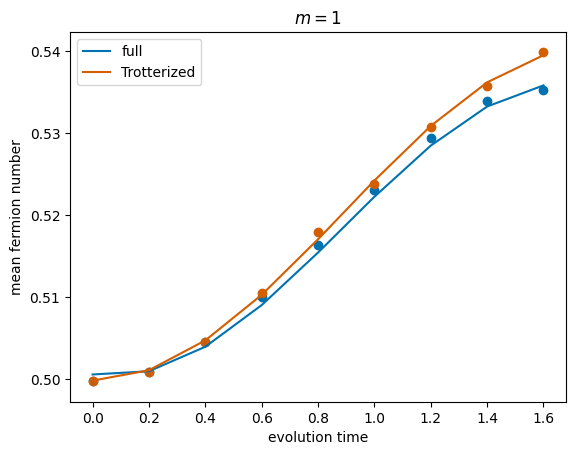

In [47]:
short_steps = np.linspace(0, 1.6, 9)

plt.scatter(short_steps, ferm_num_m1p0_e0p005[:9], color=hank_blue)
plt.plot(short_steps, [fit_func_full(item, *params_m1p0_e0p005_full) for item in short_steps], color=hank_blue, label='full')
# plt.plot(short_steps, [fit_func_trunc(item, *params_m1p0_e0p005_trunc) for item in short_steps], color=hank_blue, label='truncated', ls='dashed')
plt.errorbar(short_steps, ferm_num_m1p0_e0p005[:9], bs_error_m1p0_e0p005[:9], alpha=0.2, ls='none', color=hank_blue)

plt.scatter(short_steps, ferm_num_m1p0_trot, color=hank_orange)
plt.plot(short_steps, [fit_func_trunc(item, *params_m1p0_trot) for item in short_steps], color=hank_orange, label='Trotterized')
plt.errorbar(short_steps, ferm_num_m1p0_trot, bs_error_m1p0_trot, alpha=0.2, ls='none', color=hank_orange)

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m=1$')

plt.legend()
plt.show()

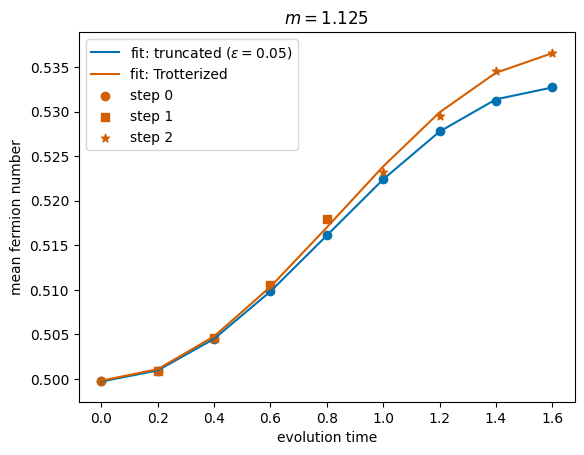

In [114]:
short_steps = np.linspace(0, 1.6, 9)

plt.scatter(short_steps, ferm_num_m1p125_e0p005[:9], color=hank_blue)
plt.plot(short_steps, [fit_func_trunc(item, *params_m1p125_e0p005_trunc) for item in short_steps], color=hank_blue, label='fit: truncated ($\\epsilon=0.05$)')
plt.errorbar(short_steps, ferm_num_m1p125_e0p005[:9], bs_error_m1p125_e0p005[:9], alpha=0.2, ls='none', color=hank_blue)

plt.plot(short_steps, [fit_func_trunc(item, *params_m1p125_trot) for item in short_steps], color=hank_orange, label='fit: Trotterized')
plt.scatter(short_steps[0], ferm_num_m1p125_trot[0], color=hank_orange, label='step 0')
plt.scatter(short_steps[1:5], ferm_num_m1p125_trot[1:5], color=hank_orange, label='step 1', marker='s')
plt.scatter(short_steps[5:], ferm_num_m1p125_trot[5:], color=hank_orange, label='step 2', marker='*')
plt.errorbar(short_steps, ferm_num_m1p125_trot, bs_error_m1p125_trot, alpha=0.2, ls='none', color=hank_orange)

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m=1.125$')

plt.legend()
plt.savefig('figures/trotter_vs_exact.pdf')
plt.show()

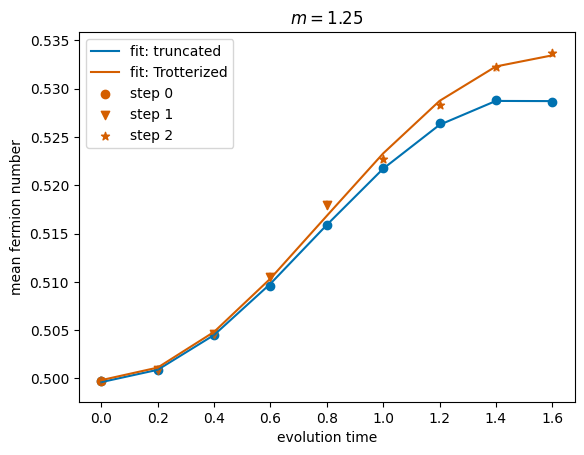

In [110]:
short_steps = np.linspace(0, 1.6, 9)

plt.scatter(short_steps, ferm_num_m1p25_e0p005[:9], color=hank_blue)
plt.plot(short_steps, [fit_func_trunc(item, *params_m1p25_e0p005_trunc) for item in short_steps], color=hank_blue, label='fit: truncated')
plt.errorbar(short_steps, ferm_num_m1p25_e0p005[:9], bs_error_m1p25_e0p005[:9], alpha=0.2, ls='none', color=hank_blue)

plt.plot(short_steps, [fit_func_trunc(item, *params_m1p25_trot) for item in short_steps], color=hank_orange, label='fit: Trotterized')
plt.scatter(short_steps[0], ferm_num_m1p25_trot[0], color=hank_orange, label='step 0')
plt.scatter(short_steps[1:5], ferm_num_m1p25_trot[1:5], color=hank_orange, marker='v', label='step 1')
plt.scatter(short_steps[5:], ferm_num_m1p25_trot[5:], color=hank_orange, marker='*', label='step 2')
plt.errorbar(short_steps, ferm_num_m1p25_trot, bs_error_m1p25_trot, alpha=0.2, ls='none', color=hank_orange)

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m=1.25$')

plt.legend()
plt.show()

# misc

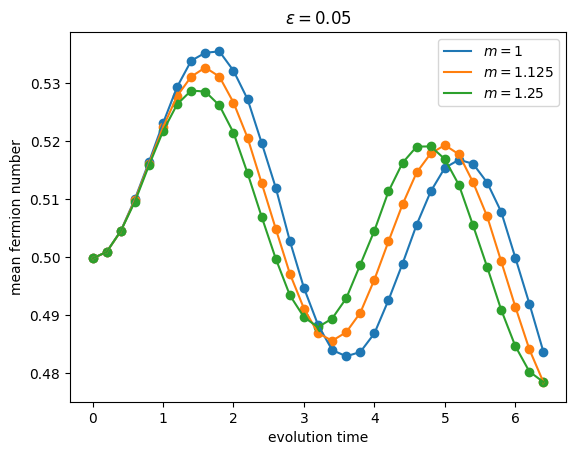

In [10]:
trotter_steps = [item*0.2 for item in range(len(ferm_num_m1p0_e0p005))]

plt.scatter(trotter_steps, ferm_num_m1p0_e0p005, color='tab:blue')
plt.errorbar(trotter_steps, ferm_num_m1p0_e0p005, bs_error_m1p0_e0p005, alpha=0.2, ls='none', color='tab:blue')
plt.plot(trotter_steps, ferm_num_m1p0_e0p005, color='tab:blue', label = '$m=1$')

plt.scatter(trotter_steps, ferm_num_m1p125_e0p005, color='tab:orange')
plt.errorbar(trotter_steps, ferm_num_m1p125_e0p005, bs_error_m1p125_e0p005, alpha=0.2, ls='none', color='tab:orange')
plt.plot(trotter_steps, ferm_num_m1p125_e0p005, color='tab:orange', label = '$m=1.125$')

plt.scatter(trotter_steps, ferm_num_mass_1p25, color='tab:green')
plt.errorbar(trotter_steps, ferm_num_mass_1p25, bs_error_mass_1p25, alpha=0.2, ls='none', color='tab:green')
plt.plot(trotter_steps, ferm_num_mass_1p25, color='tab:green', label = '$m=1.25$')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$\\epsilon = 0.05$')
plt.legend()
plt.savefig('figures/mass_scan_fermion_number.pdf')
plt.show()

In [5]:
def do_quick_mass_scan(mass):
    epsilon = 0.05
    # mass = 1.125
    ferm_num = np.zeros(0)
    bs_error = np.zeros(0)
    for i in range(9):
        step = int(4*i)
        print(i)
        num_shots = 1024**2
        circuit = trotter_stepper(step, Nqbits, epsilon, mass, mid).decompose().decompose()
        circuit.measure_all()
        res = do_run(circuit, num_shots)
        ferm_num=np.append(ferm_num, fermion_number(res, mid))
        bs_error=np.append(bs_error,bootstrap_error(res, mid, num_shots))
    return ferm_num, bs_error

In [8]:
ferm_num_mass_1p375, bs_error_mass_1p375 = do_quick_mass_scan(1.375)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32


In [7]:
ferm_num_mass_1p5, bs_error_mass_1p5 = do_quick_mass_scan(1.5)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32


In [6]:
ferm_num_mass_2p0, bs_error_mass_2p0 = do_quick_mass_scan(2)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32


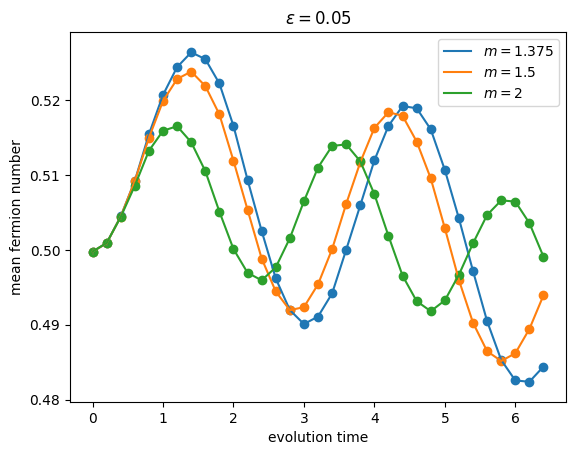

In [10]:
trotter_steps = [item*0.2 for item in range(len(ferm_num_mass_1p375))]

plt.scatter(trotter_steps, ferm_num_mass_1p375, color='tab:blue')
plt.errorbar(trotter_steps, ferm_num_mass_1p375, bs_error_mass_1p375, alpha=0.2, ls='none', color='tab:blue')
plt.plot(trotter_steps, ferm_num_mass_1p375, color='tab:blue', label = '$m=1.375$')

plt.scatter(trotter_steps, ferm_num_mass_1p5, color='tab:orange')
plt.errorbar(trotter_steps, ferm_num_mass_1p5, bs_error_mass_1p5, alpha=0.2, ls='none', color='tab:orange')
plt.plot(trotter_steps, ferm_num_mass_1p5, color='tab:orange', label = '$m=1.5$')

plt.scatter(trotter_steps, ferm_num_mass_2p0, color='tab:green')
plt.errorbar(trotter_steps, ferm_num_mass_2p0, bs_error_mass_2p0, alpha=0.2, ls='none', color='tab:green')
plt.plot(trotter_steps, ferm_num_mass_2p0, color='tab:green', label = '$m=2$')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$\\epsilon = 0.05$')
plt.legend()
plt.show()

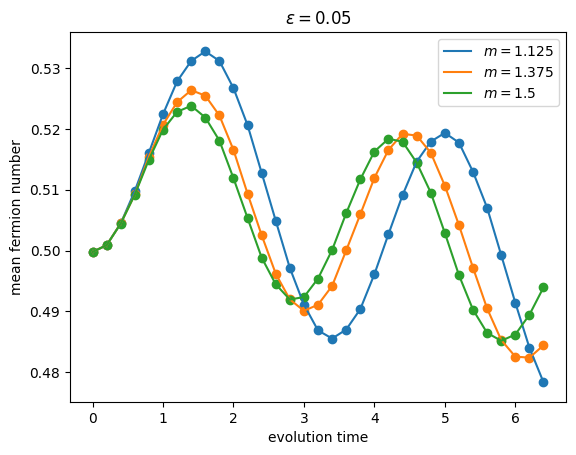

In [223]:
trotter_steps = [item*0.2 for item in range(len(ferm_num_mass_1p375))]

plt.scatter(trotter_steps, ferm_num_m1p125_e0p005, color='tab:blue')
plt.errorbar(trotter_steps, ferm_num_m1p125_e0p005, bs_error_m1p125_e0p005, alpha=0.2, ls='none', color='tab:blue')
plt.plot(trotter_steps, ferm_num_m1p125_e0p005, color='tab:blue', label = '$m=1.125$')

plt.scatter(trotter_steps, ferm_num_mass_1p375, color='tab:orange')
plt.errorbar(trotter_steps, ferm_num_mass_1p375, bs_error_mass_1p375, alpha=0.2, ls='none', color='tab:orange')
plt.plot(trotter_steps, ferm_num_mass_1p375, color='tab:orange', label = '$m=1.375$')

plt.scatter(trotter_steps, ferm_num_mass_1p5, color='tab:green')
plt.errorbar(trotter_steps, ferm_num_mass_1p5, bs_error_mass_1p5, alpha=0.2, ls='none', color='tab:green')
plt.plot(trotter_steps, ferm_num_mass_1p5, color='tab:green', label = '$m=1.5$')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$\\epsilon = 0.05$')
plt.legend()
plt.show()

## small $\epsilon$ scan, $m=1.5$

In [ ]:
def do_epsilon_scan(epsilon):
    mass = 1.5
    ferm_num = np.zeros(0)
    bs_error = np.zeros(0)
    for i in range(9):
        step = int(i*int(0.8/epsilon))
        print(i)
        num_shots = 1024**2
        circuit = trotter_stepper(step, Nqbits, epsilon, mass, mid).decompose().decompose()
        circuit.measure_all()
        res = do_run(circuit, num_shots)
        ferm_num=np.append(ferm_num, fermion_number(res, mid))
        bs_error=np.append(bs_error,bootstrap_error(res, mid, num_shots))
    return ferm_num, bs_error

In [213]:
ferm_num_eps_0p05_m_1p5, bs_error_eps_0p05_m_1p5 = do_epsilon_scan(0.05)

0
1
2
3
4
5
6
7
8


In [216]:
ferm_num_eps_0p02_m_1p5, bs_error_eps_0p02_m_1p5 = do_epsilon_scan(0.02)

0
1
2
3
4
5
6
7
8


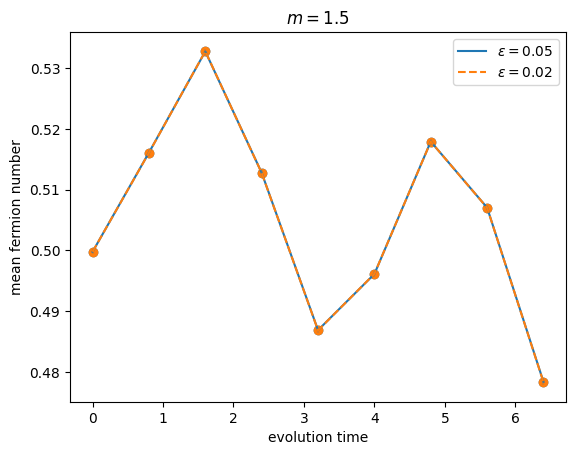

In [218]:
trotter_steps = [item*0.8 for item in range(len(ferm_num_eps_0p05_m_1p5))]

plt.scatter(trotter_steps, ferm_num_eps_0p05_m_1p5, color='tab:blue')
plt.errorbar(trotter_steps, ferm_num_eps_0p05_m_1p5, bs_error_eps_0p05_m_1p5, alpha=0.2, ls='none', color='tab:blue')
plt.plot(trotter_steps, ferm_num_eps_0p05_m_1p5, color='tab:blue', label = '$\\epsilon=0.05$')

plt.scatter(trotter_steps, ferm_num_eps_0p02_m_1p5, color='tab:orange')
plt.errorbar(trotter_steps, ferm_num_eps_0p02_m_1p5, bs_error_eps_0p02_m_1p5, alpha=0.2, ls='none', color='tab:orange')
plt.plot(trotter_steps, ferm_num_eps_0p02_m_1p5, color='tab:orange', label = '$\\epsilon=0.02$', ls='dashed')

# trotter_steps_eps_0p9_m_1 = [0.9*i for i in range(9)]
# plt.scatter(trotter_steps_eps_0p9_m_1, ferm_num_eps_0p9_m_1, color='tab:green')
# plt.errorbar(trotter_steps_eps_0p9_m_1, ferm_num_eps_0p9_m_1, bs_error_eps_0p9_m_1, alpha=0.2, ls='none', color='tab:green')
# plt.plot(trotter_steps_eps_0p9_m_1, ferm_num_eps_0p9_m_1, color='tab:green', label = '$\\epsilon=0.9$, $m=1$')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m = 1.5$')
plt.legend()
# plt.savefig('figures/mass_and_epsilon_scan_fermion_number.pdf')
plt.show()

## $\epsilon$ scan, $m=1.125$

In [28]:
def do_epsilon_scan(epsilon):
    mass = 1.125
    ferm_num = np.zeros(0)
    bs_error = np.zeros(0)
    for i in range(9):
        print(i)
        step = int(i*int(0.8/epsilon))
        num_shots = 1024**2
        circuit = trotter_stepper(step, Nqbits, epsilon, mass, mid).decompose().decompose()
        circuit.measure_all()
        res = do_run(circuit, num_shots)
        ferm_num=np.append(ferm_num, fermion_number(res, mid))
        bs_error=np.append(bs_error,bootstrap_error(res, mid, num_shots))
    return ferm_num, bs_error

In [29]:
ferm_num_eps_0p8, bs_error_eps_0p8 = do_epsilon_scan(0.8)

0
1
2
3
4
5
6
7
8


In [30]:
ferm_num_eps_0p4, bs_error_eps_0p4 = do_epsilon_scan(0.4)

0
1
2
3
4
5
6
7
8


In [31]:
ferm_num_eps_0p2, bs_error_eps_0p2 = do_epsilon_scan(0.2)

0
1
2
3
4
5
6
7
8


In [32]:
ferm_num_eps_0p1, bs_error_eps_0p1 = do_epsilon_scan(0.1)

0
1
2
3
4
5
6
7
8


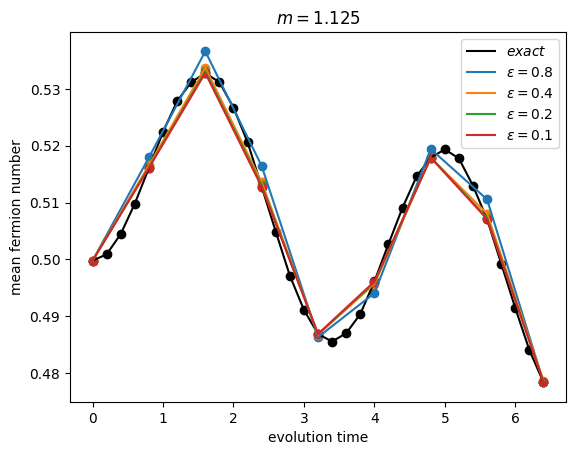

In [35]:
trotter_steps = [item*0.8 for item in range(len(ferm_num_eps_0p8))]
trotter_steps_exact = [0.2*i for i in range(33)]

# trotter_steps_1p6 = [i*(6.4/(len(ferm_num_eps_1p6)-1)) for i in range(len(ferm_num_eps_1p6))]
# plt.scatter(trotter_steps_1p6, ferm_num_eps_1p6, color='tab:brown')
# plt.errorbar(trotter_steps_1p6, ferm_num_eps_1p6, bs_error_eps_1p6, alpha=0.2, ls='none', color='tab:brown')
# plt.plot(trotter_steps_1p6, ferm_num_eps_1p6, color='tab:brown', label = '$\\epsilon=1.6$')

plt.scatter(trotter_steps_exact, ferm_num_m1125_e005, color='black')
plt.errorbar(trotter_steps_exact, ferm_num_m1125_e005, bs_error_m1125_e005, alpha=0.2, ls='none', color='black')
plt.plot(trotter_steps_exact, ferm_num_m1125_e005, color='black', label = '$exact$')

plt.scatter(trotter_steps, ferm_num_eps_0p8, color='tab:blue')
plt.errorbar(trotter_steps, ferm_num_eps_0p8, bs_error_eps_0p8, alpha=0.2, ls='none', color='tab:blue')
plt.plot(trotter_steps, ferm_num_eps_0p8, color='tab:blue', label = '$\\epsilon=0.8$')

plt.scatter(trotter_steps, ferm_num_eps_0p4, color='tab:orange')
plt.errorbar(trotter_steps, ferm_num_eps_0p4, bs_error_eps_0p4, alpha=0.2, ls='none', color='tab:orange')
plt.plot(trotter_steps, ferm_num_eps_0p4, color='tab:orange', label = '$\\epsilon=0.4$')

plt.scatter(trotter_steps, ferm_num_eps_0p2, color='tab:green')
plt.errorbar(trotter_steps, ferm_num_eps_0p2, bs_error_eps_0p2, alpha=0.2, ls='none', color='tab:green')
plt.plot(trotter_steps, ferm_num_eps_0p2, color='tab:green', label = '$\\epsilon=0.2$')

plt.scatter(trotter_steps, ferm_num_eps_0p1, color='tab:red')
plt.errorbar(trotter_steps, ferm_num_eps_0p1, bs_error_eps_0p1, alpha=0.2, ls='none', color='tab:red')
plt.plot(trotter_steps, ferm_num_eps_0p1, color='tab:red', label = '$\\epsilon=0.1$')


plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m = 1.125$')
plt.legend()
plt.savefig('figures/epsilon_scan_fermion_number.pdf')
plt.show()

## large $\epsilon$ scan, $m=1.125$

In [36]:
def do_large_epsilon_scan(epsilon):
    mass = 1.125
    ferm_num = np.zeros(0)
    bs_error = np.zeros(0)
    for i in range(int(6.4/epsilon)+1):
        step = int(i)
        print(i)
        num_shots = 1024**2
        circuit = trotter_stepper(step, Nqbits, epsilon, mass, mid).decompose().decompose()
        circuit.measure_all()
        res = do_run(circuit, num_shots)
        ferm_num=np.append(ferm_num, fermion_number(res, mid))
        bs_error=np.append(bs_error,bootstrap_error(res, mid, num_shots))
    return ferm_num, bs_error

In [37]:
epsilon = 1.0
for i in range(int(6.4/epsilon)+1):
    step = int(i)
    print(step*epsilon)

0.0
1.0
2.0
3.0
4.0
5.0
6.0


In [38]:
ferm_num_eps_0p8, bs_error_eps_0p8 = do_large_epsilon_scan(0.8)

0
1
2
3
4
5
6
7
8


In [39]:
ferm_num_eps_1p0, bs_error_eps_1p0 = do_large_epsilon_scan(1.0)

0
1
2
3
4
5
6


In [40]:
ferm_num_eps_1p2, bs_error_eps_1p2 = do_large_epsilon_scan(1.2)

0
1
2
3
4
5


In [41]:
ferm_num_eps_1p4, bs_error_eps_1p4 = do_large_epsilon_scan(1.4)

0
1
2
3
4


In [42]:
ferm_num_eps_1p6, bs_error_eps_1p6 = do_large_epsilon_scan(1.6)

0
1
2
3
4


In [43]:
def generate_trotter_steps(eps):
    return [eps*i for i in range(int(6.4/eps)+1)]

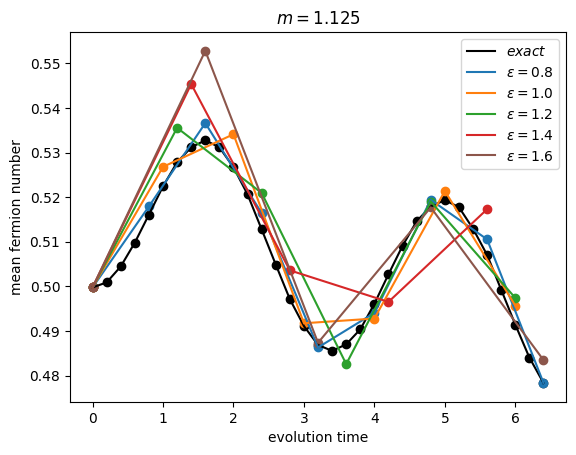

In [44]:
trotter_steps_exact = [0.2*i for i in range(33)]
plt.scatter(trotter_steps_exact, ferm_num_m1125_e005, color='black')
plt.errorbar(trotter_steps_exact, ferm_num_m1125_e005, bs_error_m1125_e005, alpha=0.2, ls='none', color='black')
plt.plot(trotter_steps_exact, ferm_num_m1125_e005, color='black', label = '$exact$')

trotter_steps_0p8 = generate_trotter_steps(0.8)
plt.scatter(trotter_steps_0p8, ferm_num_eps_0p8, color='tab:blue')
plt.errorbar(trotter_steps_0p8, ferm_num_eps_0p8, bs_error_eps_0p8, alpha=0.2, ls='none', color='tab:blue')
plt.plot(trotter_steps_0p8, ferm_num_eps_0p8, color='tab:blue', label = '$\\epsilon=0.8$')

trotter_steps_1p0 = generate_trotter_steps(1.0)
plt.scatter(trotter_steps_1p0, ferm_num_eps_1p0, color='tab:orange')
plt.errorbar(trotter_steps_1p0, ferm_num_eps_1p0, bs_error_eps_1p0, alpha=0.2, ls='none', color='tab:orange')
plt.plot(trotter_steps_1p0, ferm_num_eps_1p0, color='tab:orange', label = '$\\epsilon=1.0$')

trotter_steps_1p2 = generate_trotter_steps(1.2)
plt.scatter(trotter_steps_1p2, ferm_num_eps_1p2, color='tab:green')
plt.errorbar(trotter_steps_1p2, ferm_num_eps_1p2, bs_error_eps_1p2, alpha=0.2, ls='none', color='tab:green')
plt.plot(trotter_steps_1p2, ferm_num_eps_1p2, color='tab:green', label = '$\\epsilon=1.2$')

trotter_steps_1p4 = generate_trotter_steps(1.4)
plt.scatter(trotter_steps_1p4, ferm_num_eps_1p4, color='tab:red')
plt.errorbar(trotter_steps_1p4, ferm_num_eps_1p4, bs_error_eps_1p4, alpha=0.2, ls='none', color='tab:red')
plt.plot(trotter_steps_1p4, ferm_num_eps_1p4, color='tab:red', label = '$\\epsilon=1.4$')

trotter_steps_1p6 = generate_trotter_steps(1.6)
plt.scatter(trotter_steps_1p6, ferm_num_eps_1p6, color='tab:brown')
plt.errorbar(trotter_steps_1p6, ferm_num_eps_1p6, bs_error_eps_1p6, alpha=0.2, ls='none', color='tab:brown')
plt.plot(trotter_steps_1p6, ferm_num_eps_1p6, color='tab:brown', label = '$\\epsilon=1.6$')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m = 1.125$')
plt.legend()
plt.show()

## double scan, constant ratio

In [107]:
def do_scan(epsilon, mass):
    # mass = 1.125
    ferm_num = np.zeros(0)
    bs_error = np.zeros(0)
    for i in range(9):
        print(i)
        step = int(i)
        num_shots = 1024**2
        circuit = trotter_stepper(step, Nqbits, epsilon, mass, mid).decompose().decompose()
        circuit.measure_all()
        res = do_run(circuit, num_shots)
        ferm_num=np.append(ferm_num, fermion_number(res, mid))
        bs_error=np.append(bs_error,bootstrap_error(res, mid, num_shots))
    return ferm_num, bs_error

In [108]:
ferm_num_eps_0p72_m_1p25, bs_error_eps_0p72_m_1p25 = do_scan(0.72, 1.25)

0
1
2
3
4
5
6
7
8


In [110]:
ferm_num_eps_0p8_m_1p125, bs_error_eps_0p72_m_1p125 = do_scan(0.8, 1.125)

0
1
2
3
4
5
6
7
8


In [116]:
ferm_num_eps_0p9_m_1, bs_error_eps_0p9_m_1 = do_scan(0.9, 1)

0
1
2
3
4
5
6
7
8


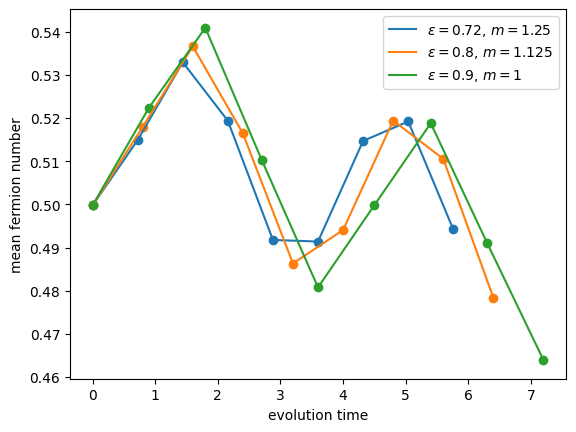

In [128]:
trotter_steps = [item*0.8 for item in range(len(ferm_num_eps_0p8))]
trotter_steps_exact = [0.2*i for i in range(33)]

trotter_steps_eps_0p72_m_1p25 = [0.72*i for i in range(9)]
plt.scatter(trotter_steps_eps_0p72_m_1p25, ferm_num_eps_0p72_m_1p25, color='tab:blue')
plt.errorbar(trotter_steps_eps_0p72_m_1p25, ferm_num_eps_0p72_m_1p25, bs_error_eps_0p72_m_1p25, alpha=0.2, ls='none', color='tab:blue')
plt.plot(trotter_steps_eps_0p72_m_1p25, ferm_num_eps_0p72_m_1p25, color='tab:blue', label = '$\\epsilon=0.72$, $m=1.25$')

trotter_steps_eps_0p8_m_1p125 = [0.8*i for i in range(9)]
plt.scatter(trotter_steps_eps_0p8_m_1p125, ferm_num_eps_0p8_m_1p125, color='tab:orange')
plt.errorbar(trotter_steps_eps_0p8_m_1p125, ferm_num_eps_0p8_m_1p125, bs_error_eps_0p72_m_1p125, alpha=0.2, ls='none', color='tab:orange')
plt.plot(trotter_steps_eps_0p8_m_1p125, ferm_num_eps_0p8_m_1p125, color='tab:orange', label = '$\\epsilon=0.8$, $m=1.125$')

trotter_steps_eps_0p9_m_1 = [0.9*i for i in range(9)]
plt.scatter(trotter_steps_eps_0p9_m_1, ferm_num_eps_0p9_m_1, color='tab:green')
plt.errorbar(trotter_steps_eps_0p9_m_1, ferm_num_eps_0p9_m_1, bs_error_eps_0p9_m_1, alpha=0.2, ls='none', color='tab:green')
plt.plot(trotter_steps_eps_0p9_m_1, ferm_num_eps_0p9_m_1, color='tab:green', label = '$\\epsilon=0.9$, $m=1$')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
# plt.title('$m = 1.125$')
plt.legend()
plt.savefig('figures/mass_and_epsilon_scan_fermion_number.pdf')
plt.show()

## large $\epsilon$, large $m$

In [17]:
def do_eps_scan(mass):
    # mass = 1.125
    ferm_num = np.zeros(0)
    bs_error = np.zeros(0)
    for i in range(9):
        print(i)
        if i == 0:
            step, epsilon = 0, 1
        elif i <= 4:
            step, epsilon = 1, np.round(0.2*i, 1)
        else:
            step, epsilon = 2, np.round(i*0.1, 1)
        num_shots = 1024**2
        circuit = trotter_stepper(step, Nqbits, epsilon, mass, mid).decompose().decompose()
        circuit.measure_all()
        res = do_run(circuit, num_shots)
        ferm_num=np.append(ferm_num, fermion_number(res, mid))
        bs_error=np.append(bs_error,bootstrap_error(res, mid, num_shots))
    return ferm_num, bs_error

In [37]:
ferm_num_eps_scan_m_2p0, bs_error_eps_scan_m_2p0 = do_eps_scan(2)

0
1
2
3
4
5
6
7
8


In [18]:
ferm_num_eps_scan_m_1p25, bs_error_eps_scan_m_1p25 = do_eps_scan(1.25)

0
1
2
3
4
5
6
7
8


In [19]:
ferm_num_eps_scan_m_1p125, bs_error_eps_scan_m_1p125 = do_eps_scan(1.125)

0
1
2
3
4
5
6
7
8


In [20]:
ferm_num_eps_scan_m_1p0, bs_error_eps_scan_m_1p0 = do_eps_scan(1)

0
1
2
3
4
5
6
7
8


In [27]:
np.save('mass_scan_plot_data/ferm_num_eps_scan_m_1p0.npy', ferm_num_eps_scan_m_1p0)
np.save('mass_scan_plot_data/ferm_num_eps_scan_m_1p125.npy', ferm_num_eps_scan_m_1p125)
np.save('mass_scan_plot_data/ferm_num_eps_scan_m_1p25.npy', ferm_num_eps_scan_m_1p25)

np.save('mass_scan_plot_data/bs_error_eps_scan_m_1p0.npy', bs_error_eps_scan_m_1p0)
np.save('mass_scan_plot_data/bs_error_eps_scan_m_1p125.npy', bs_error_eps_scan_m_1p125)
np.save('mass_scan_plot_data/bs_error_eps_scan_m_1p25.npy', bs_error_eps_scan_m_1p25)

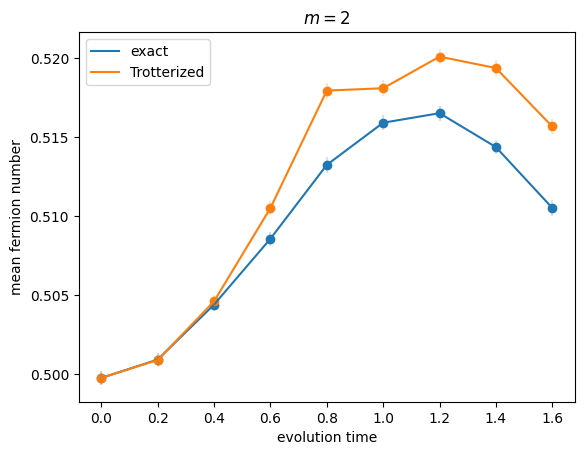

In [59]:
short_num = len(ferm_num_eps_scan_m_2p0)
trotter_steps = [item*0.2 for item in range(short_num)]

plt.scatter(trotter_steps, ferm_num_mass_2p0[:short_num], color='tab:blue')
plt.errorbar(trotter_steps, ferm_num_mass_2p0[:short_num], bs_error_mass_2p0[:short_num], alpha=0.2, ls='none', color='tab:blue')
plt.plot(trotter_steps, ferm_num_mass_2p0[:short_num], color='tab:blue', label = 'exact')

plt.scatter(trotter_steps, ferm_num_eps_scan_m_2p0, color='tab:orange')
plt.errorbar(trotter_steps, ferm_num_eps_scan_m_2p0, bs_error_eps_scan_m_2p0, alpha=0.2, ls='none', color='tab:orange')
plt.plot(trotter_steps, ferm_num_eps_scan_m_2p0, color='tab:orange', label = 'Trotterized')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m=2$')
plt.legend()
plt.show()

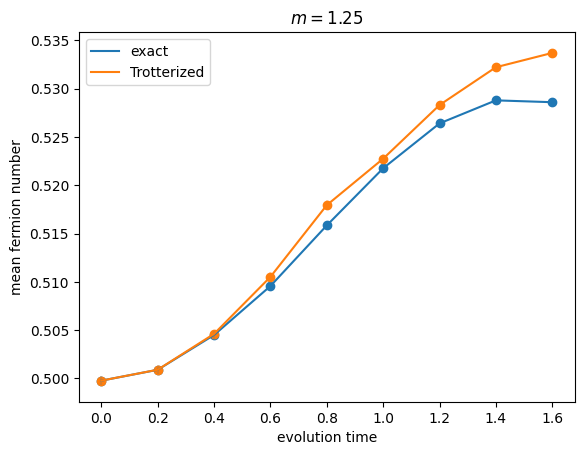

In [24]:
short_num = len(ferm_num_eps_scan_m_1p25)
trotter_steps = [item*0.2 for item in range(short_num)]

plt.scatter(trotter_steps, ferm_num_mass_1p25[:short_num], color='tab:blue')
plt.errorbar(trotter_steps, ferm_num_mass_1p25[:short_num], bs_error_mass_1p25[:short_num], alpha=0.2, ls='none', color='tab:blue')
plt.plot(trotter_steps, ferm_num_mass_1p25[:short_num], color='tab:blue', label = 'exact')

plt.scatter(trotter_steps, ferm_num_eps_scan_m_1p25, color='tab:orange')
plt.errorbar(trotter_steps, ferm_num_eps_scan_m_1p25, bs_error_eps_scan_m_1p25, alpha=0.2, ls='none', color='tab:orange')
plt.plot(trotter_steps, ferm_num_eps_scan_m_1p25, color='tab:orange', label = 'Trotterized')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m=1.25$')
plt.legend()
plt.show()

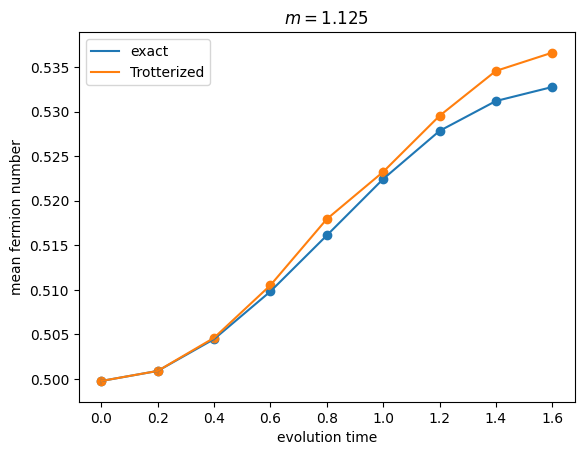

In [25]:
short_num = len(ferm_num_eps_scan_m_1p125)
trotter_steps = [item*0.2 for item in range(short_num)]

plt.scatter(trotter_steps, ferm_num_m1p125_e0p005[:short_num], color='tab:blue')
plt.errorbar(trotter_steps, ferm_num_m1p125_e0p005[:short_num], bs_error_m1p125_e0p005[:short_num], alpha=0.2, ls='none', color='tab:blue')
plt.plot(trotter_steps, ferm_num_m1p125_e0p005[:short_num], color='tab:blue', label = 'exact')

plt.scatter(trotter_steps, ferm_num_eps_scan_m_1p125, color='tab:orange')
plt.errorbar(trotter_steps, ferm_num_eps_scan_m_1p125, bs_error_eps_scan_m_1p125, alpha=0.2, ls='none', color='tab:orange')
plt.plot(trotter_steps, ferm_num_eps_scan_m_1p125, color='tab:orange', label = 'Trotterized')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m=1.125$')
plt.legend()
plt.show()

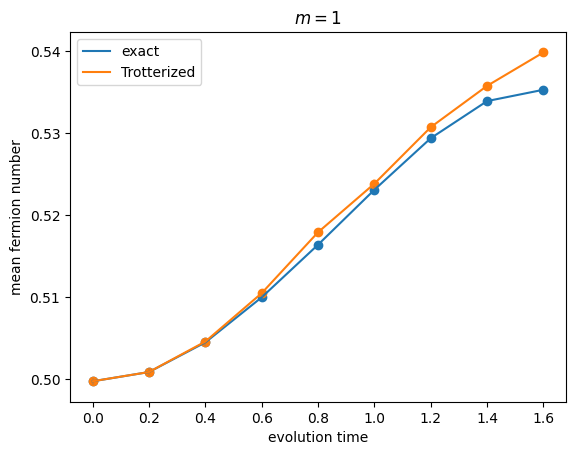

In [63]:
short_num = len(ferm_num_eps_scan_m_1p0)
trotter_steps = [item*0.2 for item in range(short_num)]

plt.scatter(trotter_steps, ferm_num_m1p0_e0p005[:short_num], color='tab:blue')
plt.errorbar(trotter_steps, ferm_num_m1p0_e0p005[:short_num], bs_error_m1p0_e0p005[:short_num], alpha=0.2, ls='none', color='tab:blue')
plt.plot(trotter_steps, ferm_num_m1p0_e0p005[:short_num], color='tab:blue', label = 'exact')

plt.scatter(trotter_steps, ferm_num_eps_scan_m_1p0, color='tab:orange')
plt.errorbar(trotter_steps, ferm_num_eps_scan_m_1p0, bs_error_eps_scan_m_1p0, alpha=0.2, ls='none', color='tab:orange')
plt.plot(trotter_steps, ferm_num_eps_scan_m_1p0, color='tab:orange', label = 'Trotterized')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m=1$')
plt.legend()
plt.show()

In [49]:
def fit_func(x, A, B, C, D, E):
    return A*np.exp(-B*x) * np.cos(C*x) + D + E*x

In [72]:
params_m1_exact_full, _ = curve_fit(fit_func, [item*0.2 for item in range(len(ferm_num_m1p0_e0p005))], ferm_num_m1p0_e0p005, sigma=bs_error_m1p0_e0p005)

In [73]:
params_m1_exact_full

array([-0.0224192 ,  0.00802858,  1.77045717,  0.5230205 , -0.00516535])

In [75]:
params_m1_exact_trunc, _ = curve_fit(fit_func, [item*0.2 for item in range(9)], ferm_num_m1p0_e0p005[:9], sigma=bs_error_m1p0_e0p005[:9], p0=params_m1_exact_full)

In [76]:
params_m1_exact_trunc

array([-0.0115615 , -0.26016588,  2.10654822,  0.51127581,  0.0043893 ])

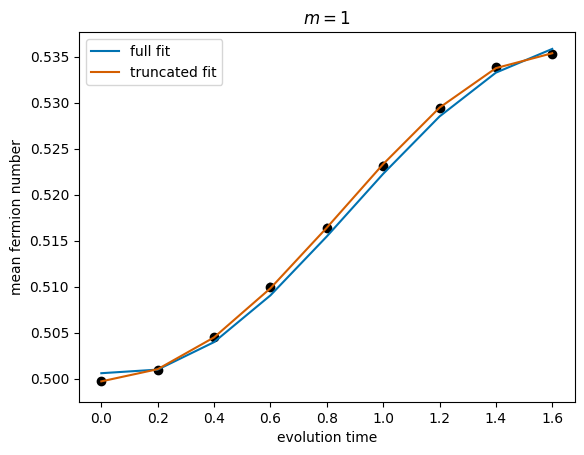

In [106]:
plt.scatter(trotter_steps, ferm_num_m1p0_e0p005[:short_num], color='black')
plt.errorbar(trotter_steps, ferm_num_m1p0_e0p005[:short_num], bs_error_m1p0_e0p005[:short_num], alpha=0.2, ls='none', color='black')
plt.plot(trotter_steps, [fit_func(0.2*i, *params_m1_exact_full) for i in range(9)], color=hank_blue, label = 'full fit')
plt.plot(trotter_steps, [fit_func(0.2*i, *params_m1_exact_trunc) for i in range(9)], color=hank_orange, label = 'truncated fit')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m=1$')

plt.legend()
plt.show()

In [89]:
params_m1p125_full, _ = curve_fit(fit_func, [item*0.2 for item in range(len(ferm_num_m1p125_e0p005))], ferm_num_m1p125_e0p005, sigma=bs_error_m1p125_e0p005)

In [90]:
params_m1p125_full

array([-0.01958994, -0.00256387,  1.87138898,  0.51953809, -0.00403299])

In [92]:
params_m1p125_trunc, _ = curve_fit(fit_func, [item*0.2 for item in range(9)], ferm_num_m1p125_e0p005[:9], sigma=bs_error_m1p125_e0p005[:9], p0=params_m1p125_full)

In [93]:
params_m1p125_trunc

array([-0.02103869,  0.1026963 ,  1.84276735,  0.52081398, -0.00350905])

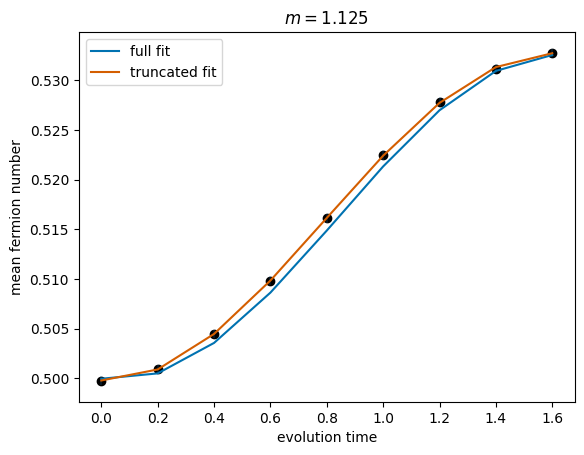

In [112]:
plt.scatter(trotter_steps, ferm_num_m1p125_e0p005[:short_num], color='black')
plt.errorbar(trotter_steps, ferm_num_m1p125_e0p005[:short_num], bs_error_m1p125_e0p005[:short_num], alpha=0.2, ls='none', color='tab:blue')
plt.plot(trotter_steps, [fit_func(0.2*i, *params_m1p125_full) for i in range(9)], color=hank_blue, label = 'full fit')
plt.plot(trotter_steps, [fit_func(0.2*i, *params_m1p125_trunc) for i in range(9)], color=hank_orange, label = 'truncated fit')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('$m=1.125$')

plt.legend()
plt.show()